In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Instrukcje
Zaimplementuj, wytrenuj i przetestuj model sieci neuronowej do klasyfikacji obrazów z zestawu danych CIFAR-10. Zestaw danych składa się z 60 000 kolorowych obrazów (32×32 piksele) podzielonych na 10 klas, w tym samochody, psy, statki i inne.

Wytyczne dotyczące modelu:
- Użyj warstw Conv2D, Dropout, Dense, MaxPooling2D i Flatten.
- Jeśli sieć zawiera więcej niż 10 warstw, użyj kernel_initializer, aby poprawić wydajność i zapobiec problemowi zanikającego gradientu.

Kryteria oceny:
Wydajność Twojego modelu będzie oceniana na podstawie końcowej dokładności danych testowych:
- Dokładność < 0,599 → 0 punktów
- 0,600 < Dokładność < 0,699 → 7 punktów
- 0,700 < Dokładność > 0,779 → 9 punktów
- 0,78 < Dokładność > 0,799 → 12 punktów
- Dokładność > 0,800 → 14 punktów

Wymagane wyniki (do uwzględnienia w raporcie):
- Wizualizacja architektury sieciowej
- Wyeksportowany plik modelu (`.keras`)
- Macierz pomyłek
- Wykres historii uczenia (krzywe dokładności/strat)
- Końcowa dokładność danych testowych
- Kod źródłowy
Moja praca



In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test)=cifar10.load_data()

print('Shape of x_train is {}'.format(x_train.shape))
print('Shape of x_test is {}'.format(x_test.shape))
print('Shape of y_train is {}'.format(y_train.shape))
print('Shape of y_test is {}'.format(y_test.shape))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Shape of x_train is (50000, 32, 32, 3)
Shape of x_test is (10000, 32, 32, 3)
Shape of y_train is (50000, 1)
Shape of y_test is (10000, 1)


 (50000, 32, 32, 3) -> Oznacza to 50 tysięcy obrazków, z których każdy ma 32x32 piksele, a każdy piksel ma 3 kolory (RGB).

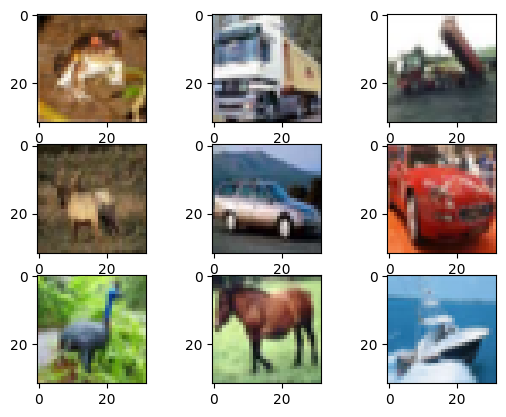

In [ ]:
from matplotlib import pyplot

for i in range(9):
	# define subplot
	pyplot.subplot(330 + 1 + i)
	# plot raw pixel data
	pyplot.imshow(x_train[i])
# show the figure
pyplot.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from matplotlib import pyplot

def load_dataset():
    # 1. Ładowanie danych
    (trainX, trainY), (testX, testY) = cifar10.load_data()

    # 2. One-hot encoding (zamiana etykiet 0-9 na wektory binarne)
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)

    return trainX, trainY, testX, testY

def prep_pixels(train, test):
    # Konwersja na liczby zmiennoprzecinkowe i normalizacja do zakresu 0-1
    train_norm = train.astype('float32') / 255.0
    test_norm = test.astype('float32') / 255.0
    return train_norm, test_norm

# Wywołanie funkcji
x_train, y_train, x_test, y_test = load_dataset()
x_train, x_test = prep_pixels(x_train, x_test)

print(f'Shape of x_train: {x_train.shape}')
print('Shape of y_train is {}'.format(y_train.shape))


Shape of x_train: (50000, 32, 32, 3)
Shape of y_train is (50000, 10)


# SGD

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def load_dataset():
    (trainX, trainY), (testX, testY) = cifar10.load_data()
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY

def prep_pixels(train, test):
    return train.astype('float32') / 255.0, test.astype('float32') / 255.0

def define_model():
    model = Sequential()

    init = 'he_uniform'

    # Blok 1
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer=init, padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2)) # Zapobieganie overfittingowi

    # Blok 2
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))

    # Blok 3
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.4))

    # Klasyfikator
    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_initializer=init))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax')) # 10 klas wyjściowych

    # Optymalizacja
    opt = SGD(learning_rate=0.001, momentum=0.9)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def run_test_harness():
    trainX, trainY, testX, testY = load_dataset()
    trainX, testX = prep_pixels(trainX, testX)

    model = define_model()

    #trenowanie
    history = model.fit(trainX, trainY, epochs=100, batch_size=64, validation_split=0.2, verbose=1)

    #ocena
    _, acc = model.evaluate(testX, testY, verbose=0)
    print(f'> Finalna dokładność: {acc:.3f}')

    # Zapisywanie modelu
    model.save('model_sgd.keras')

    return model, history, testX, testY

# Wywołanie
model, history, testX, testY = run_test_harness()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.1412 - loss: 2.2546 - val_accuracy: 0.2251 - val_loss: 2.0815
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.2315 - loss: 2.0208 - val_accuracy: 0.3162 - val_loss: 1.8690
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.2947 - loss: 1.8652 - val_accuracy: 0.3623 - val_loss: 1.7462
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3438 - loss: 1.7520 - val_accuracy: 0.4077 - val_loss: 1.6143
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3726 - loss: 1.6769 - val_accuracy: 0.4312 - val_loss: 1.5606
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3992 - loss: 1.6205 - val_accuracy: 0.4640 - val_loss: 1.4865
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4213 - loss: 1.5641 - val_accuracy: 0.4728 - val_loss: 1.4368
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4444 - loss: 1.5057 - val_ac

In [ ]:
model.save('/content/drive/MyDrive/cifar-10-sgd/model_sgd.keras')

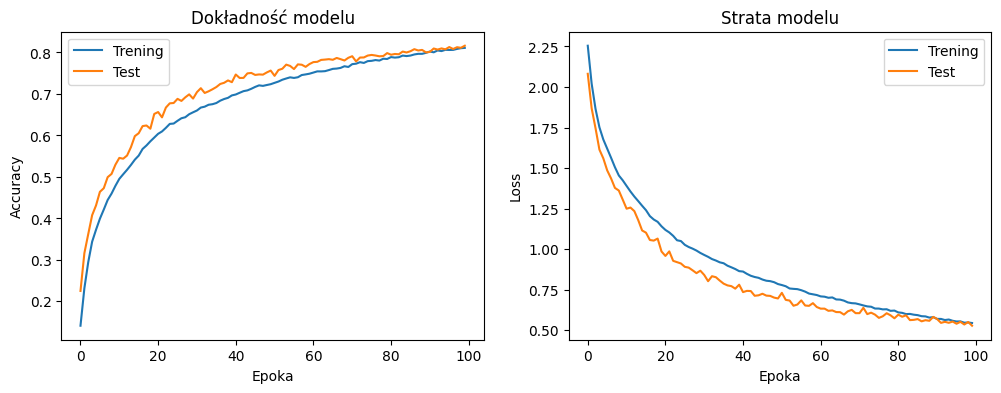

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title('Strata modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


<Figure size 1000x800 with 0 Axes>

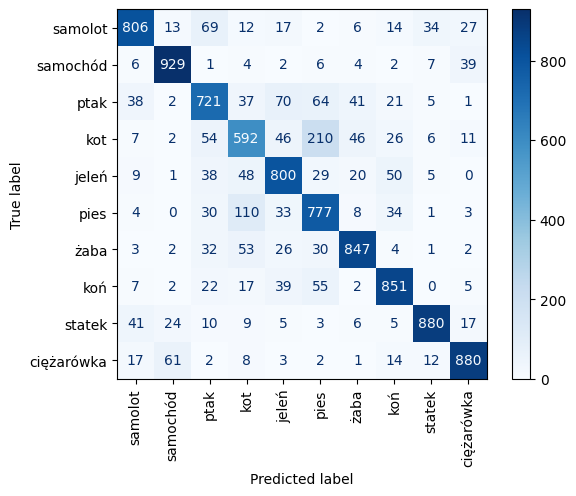

In [ ]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(testY, axis=1)

classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,101,142 (4.20 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 550,572 (2.10 MB)

# SGD + argumentacja

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def load_dataset():
    (trainX, trainY), (testX, testY) = cifar10.load_data()
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY

def prep_pixels(train, test):
    return train.astype('float32') / 255.0, test.astype('float32') / 255.0

def define_model():
    model = Sequential()

    init = 'he_uniform'

    # Blok 1
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer=init, padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2)) # Zapobieganie overfittingowi

    # Blok 2
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))

    # Blok 3
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.4))

    # Klasyfikator
    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_initializer=init))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax')) # 10 klas wyjściowych


    opt = SGD(learning_rate=0.001, momentum=0.9)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

def run_test_harness():
    trainX, trainY, testX, testY = load_dataset()
    trainX, testX = prep_pixels(trainX, testX)

    model = define_model()

    #argumentacja
    datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, validation_split=0.2)
    it_train = datagen.flow(trainX, trainY, batch_size=64, subset='training', seed=42)
    it_val = datagen.flow(trainX, trainY, batch_size=64, subset='validation', seed=42)
    steps = int((trainX.shape[0] * 0.8) / 64)
    val_steps = int((trainX.shape[0] * 0.2) / 64)

    history = model.fit(it_train, steps_per_epoch=steps, epochs=100, batch_size=64, validation_data=it_val, validation_steps=val_steps, verbose=1)

    _, acc = model.evaluate(testX, testY, verbose=0)
    print(f'> Finalna dokładność: {acc:.3f}')

    model.save('model_sgd_argumentacja.keras')

    return model, history, testX, testY

# Wywołanie
model, history, testX, testY = run_test_harness()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.1541 - loss: 2.2206 - val_accuracy: 0.2514 - val_loss: 2.0477
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.2417 - loss: 2.0083 - val_accuracy: 0.3092 - val_loss: 1.8834
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.2862 - loss: 1.8858 - val_accuracy: 0.3474 - val_loss: 1.7607
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.3224 - loss: 1.7981 - val_accuracy: 0.3786 - val_loss: 1.6875
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.3474 - loss: 1.7372 - val_accuracy: 0.4079 - val_loss: 1.5841
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.3718 - loss: 1.6839 - val_accuracy: 0.4322 - val_loss: 1.5459
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.3869 - loss: 1.6388 - val_accuracy: 0.4473 - val_loss: 1.5276
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.4061 - loss: 1

In [ ]:
model.save('/content/drive/MyDrive/cifar-10-sgd/model_sgd_argumentacja.keras')


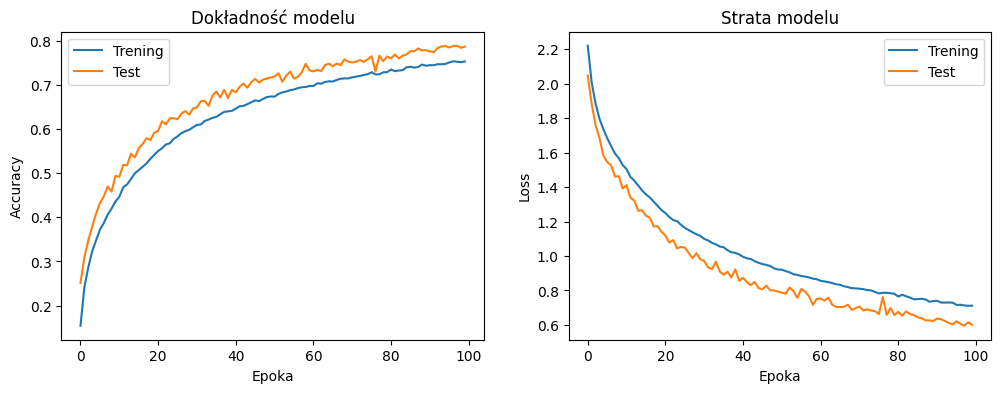

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title('Strata modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


<Figure size 1000x800 with 0 Axes>

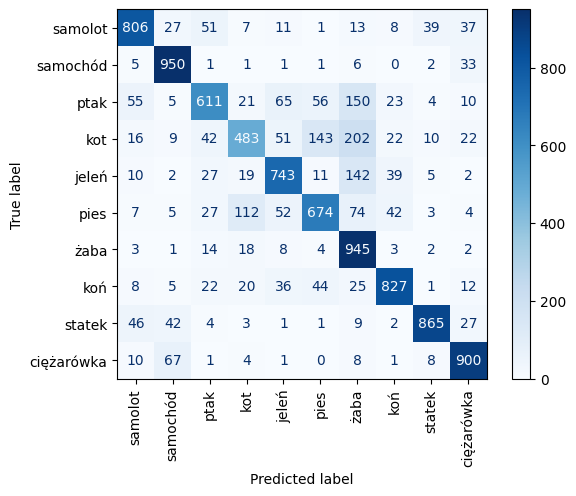

In [ ]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(testY, axis=1)

classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,101,142 (4.20 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 550,572 (2.10 MB)

# SGD + argumentacja dalsze 200 epok

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator # DODANE: import generatora

def prep_pixels(train, test):
    return train.astype('float32') / 255.0, test.astype('float32') / 255.0

def load_dataset():
    (trainX, trainY), (testX, testY) = cifar10.load_data()
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY

trainX, trainY, testX, testY = load_dataset()
trainX, testX = prep_pixels(trainX, testX)

datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, validation_split=0.2)
it_train = datagen.flow(trainX, trainY, batch_size=64, subset='training', seed=42)
it_val = datagen.flow(trainX, trainY, batch_size=64, subset='validation', seed=42)
steps = int((trainX.shape[0] * 0.8) / 64)
val_steps = int((trainX.shape[0] * 0.2) / 64)

model = tf.keras.models.load_model('/content/drive/MyDrive/cifar-10-sgd/model_sgd_argumentacja.keras')

# ZMIENIONE: Użycie generatora (it_train) i kroków (steps_per_epoch) zamiast surowych tablic trainX i trainY
history = model.fit(
    it_train,
    steps_per_epoch=steps,
    epochs=200,
    initial_epoch=100,
    validation_data=it_val, validation_steps=val_steps,
    verbose=1
)


model.save('model_sgd_argumentacja_200epok.keras')

_, acc = model.evaluate(testX, testY, verbose=0)
print(f'> Finalna dokładność najlepszego modelu po kontynuacji: {acc:.3f}')

Epoch 101/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 54ms/step - accuracy: 0.7549 - loss: 0.7057 - val_accuracy: 0.7824 - val_loss: 0.6255
Epoch 102/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.7559 - loss: 0.7021 - val_accuracy: 0.7871 - val_loss: 0.6026
Epoch 103/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.7584 - loss: 0.7010 - val_accuracy: 0.7894 - val_loss: 0.5852
Epoch 104/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.7605 - loss: 0.6957 - val_accuracy: 0.7948 - val_loss: 0.6005
Epoch 105/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.7580 - loss: 0.6954 - val_accuracy: 0.7957 - val_loss: 0.5877
Epoch 106/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.7584 - loss: 0.6950 - val_accuracy: 0.7911 - val_loss: 0.5915
Epoch 107/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step - accuracy: 0.7614 - loss: 0.6890 - val_accuracy: 0.7903 - val_loss: 0.5986
Epoch 108/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 

In [ ]:
model.save('/content/drive/MyDrive/cifar-10-sgd/model_sgd_argumentacja_200epok.keras')


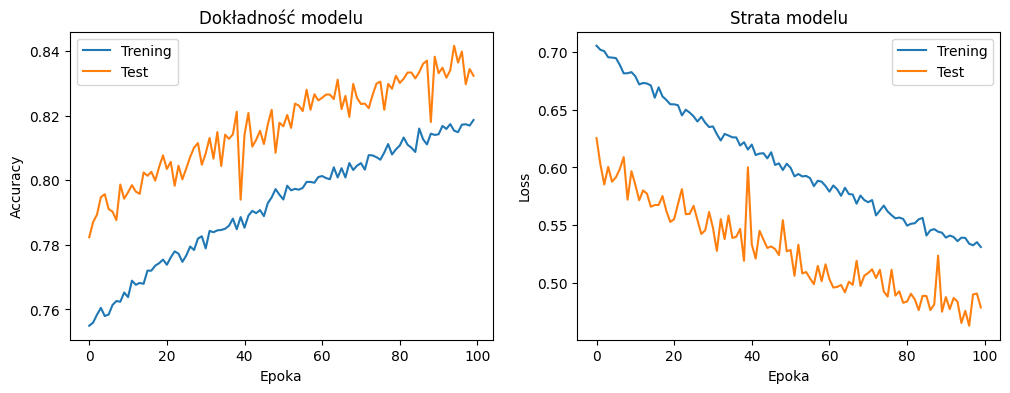

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title('Strata modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


<Figure size 1000x800 with 0 Axes>

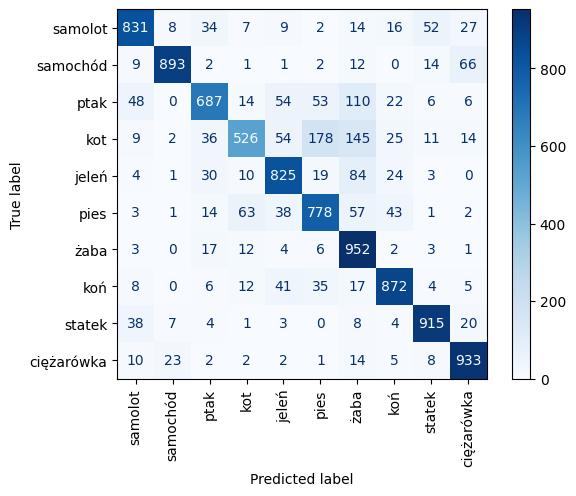

In [ ]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(testY, axis=1)

classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,101,142 (4.20 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 550,572 (2.10 MB)

# SGD + argumentacja >200 epok

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # DODANE: import callbacków
import math # DODANE: import math dla ceil

def prep_pixels(train, test):
    return train.astype('float32') / 255.0, test.astype('float32') / 255.0

def load_dataset():
    (trainX, trainY), (testX, testY) = cifar10.load_data()
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY

trainX, trainY, testX, testY = load_dataset()
trainX, testX = prep_pixels(trainX, testX)

datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, validation_split=0.2)
it_train = datagen.flow(trainX, trainY, batch_size=64, subset='training', seed=42)
it_val = datagen.flow(trainX, trainY, batch_size=64, subset='validation', seed=42)

steps_per_epoch = math.ceil((trainX.shape[0] * 0.8) / 64)
val_steps = math.ceil((trainX.shape[0] * 0.2) / 64)

model = tf.keras.models.load_model('/content/drive/MyDrive/cifar-10-sgd/model_sgd_argumentacja_200epok.keras')

es = EarlyStopping(monitor='val_accuracy', mode='max', patience=20, verbose=1)
mc = ModelCheckpoint('/content/drive/MyDrive/cifar-10-sgd/final_model_sgd_argumentacja_bestv2.keras', monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

history = model.fit(
    it_train,
    steps_per_epoch=steps_per_epoch,
    epochs=300,
    initial_epoch=200,
    validation_data=it_val, validation_steps=val_steps,
    verbose=1,
    callbacks=[es, mc] # DODANE: Callbacki do treningu
)

# Wczytanie najlepszego zapisanego modelu do oceny
saved_model = tf.keras.models.load_model('/content/drive/MyDrive/cifar-10-sgd/final_model_sgd_argumentacja_bestv2.keras')

_, acc = saved_model.evaluate(testX, testY, verbose=0)
print(f'> Finalna dokładność najlepszego modelu po kontynuacji: {acc:.3f}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 201/300
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8257 - loss: 0.5118
Epoch 201: val_accuracy improved from None to 0.84010, saving model to /content/drive/MyDrive/cifar-10-sgd/final_model_sgd_argumentacja_bestv2.keras

Epoch 201: finished saving model to /content/drive/MyDrive/cifar-10-sgd/final_model_sgd_argumentacja_bestv2.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.8226 - loss: 0.5177 - val_accuracy: 0.8401 - val_loss: 0.4652
Epoch 202/300
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8223 - loss: 0.5102
Epoch 202: val_accuracy improved from 0.84010 to 0.84050, saving model to /content/drive/MyDrive/cifar-10-sgd/final_model_sgd_argumentacja_bestv2.keras

Epoch 202: finished saving model to /content/drive/MyDrive/cifar-10-sgd/final_model_sgd_argumentacja_bestv2.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.8223 - loss: 0.5169 - val_accuracy: 0.8405 - val_loss: 0.468

In [3]:
saved_model = tf.keras.models.load_model('/content/drive/MyDrive/cifar-10-sgd/final_model_sgd_argumentacja_bestv2.keras')


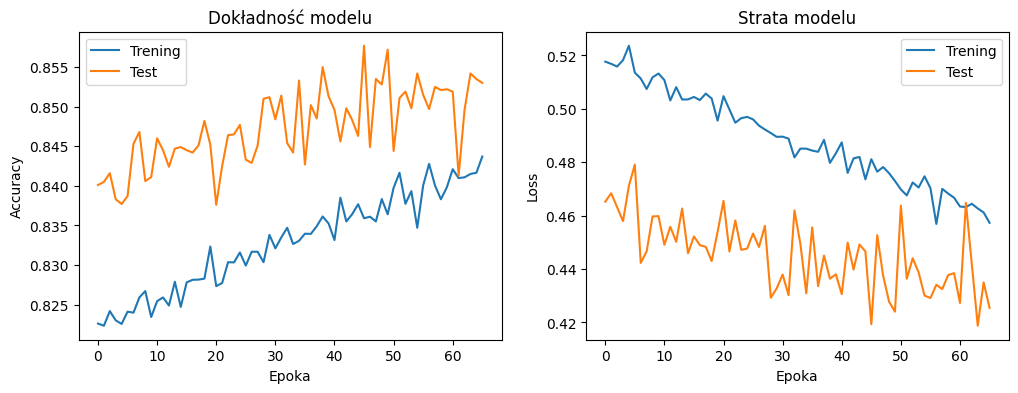

In [4]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title('Strata modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


<Figure size 1000x800 with 0 Axes>

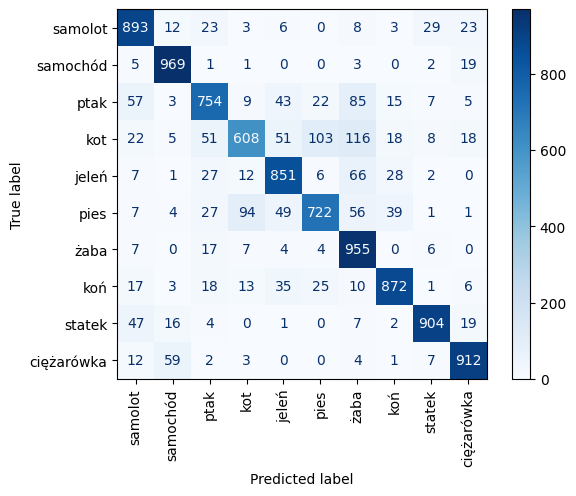

In [5]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(testY, axis=1)

classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [6]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,101,142 (4.20 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 550,572 (2.10 MB)

In [10]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # DODANE: import callbacków
import math # DODANE: import math dla ceil

def prep_pixels(train, test):
    return train.astype('float32') / 255.0, test.astype('float32') / 255.0

def load_dataset():
    (trainX, trainY), (testX, testY) = cifar10.load_data()
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY

trainX, trainY, testX, testY = load_dataset()
trainX, testX = prep_pixels(trainX, testX)

datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, validation_split=0.2)
it_train = datagen.flow(trainX, trainY, batch_size=64, subset='training', seed=42)
it_val = datagen.flow(trainX, trainY, batch_size=64, subset='validation', seed=42)

steps_per_epoch = math.ceil((trainX.shape[0] * 0.8) / 64)
val_steps = math.ceil((trainX.shape[0] * 0.2) / 64)

model = tf.keras.models.load_model('/content/drive/MyDrive/cifar-10-sgd/final_model_sgd_argumentacja_bestv2.keras')

es = EarlyStopping(monitor='val_accuracy', mode='max', patience=20, verbose=1)
mc = ModelCheckpoint('/content/drive/MyDrive/cifar-10-sgd/final_model_sgd_argumentacja_bestv3.keras', monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

history = model.fit(
    it_train,
    steps_per_epoch=steps_per_epoch,
    epochs=400,
    initial_epoch=266,
    validation_data=it_val, validation_steps=val_steps,
    verbose=1,
    callbacks=[es, mc] # DODANE: Callbacki do treningu
)

# Wczytanie najlepszego zapisanego modelu do oceny
saved_model = tf.keras.models.load_model('/content/drive/MyDrive/cifar-10-sgd/final_model_sgd_argumentacja_bestv3.keras')

_, acc = saved_model.evaluate(testX, testY, verbose=0)
print(f'> Finalna dokładność najlepszego modelu po kontynuacji: {acc:.3f}')

Epoch 267/400
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8379 - loss: 0.4728
Epoch 267: val_accuracy improved from None to 0.85060, saving model to /content/drive/MyDrive/cifar-10-sgd/final_model_sgd_argumentacja_bestv3.keras

Epoch 267: finished saving model to /content/drive/MyDrive/cifar-10-sgd/final_model_sgd_argumentacja_bestv3.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - accuracy: 0.8368 - loss: 0.4759 - val_accuracy: 0.8506 - val_loss: 0.4377
Epoch 268/400
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8361 - loss: 0.4703
Epoch 268: val_accuracy did not improve from 0.85060
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - accuracy: 0.8364 - loss: 0.4741 - val_accuracy: 0.8461 - val_loss: 0.4472
Epoch 269/400
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8383 - loss: 0.4746
Epoch 269: val_accuracy did not improve from 0.85060
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.8367 - loss: 0.4787 - val_accuracy: 0.8427 - val_loss: 0.4606
Epo

In [7]:
import pydot
import graphviz

!pip install pydot
!apt-get install graphviz -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.


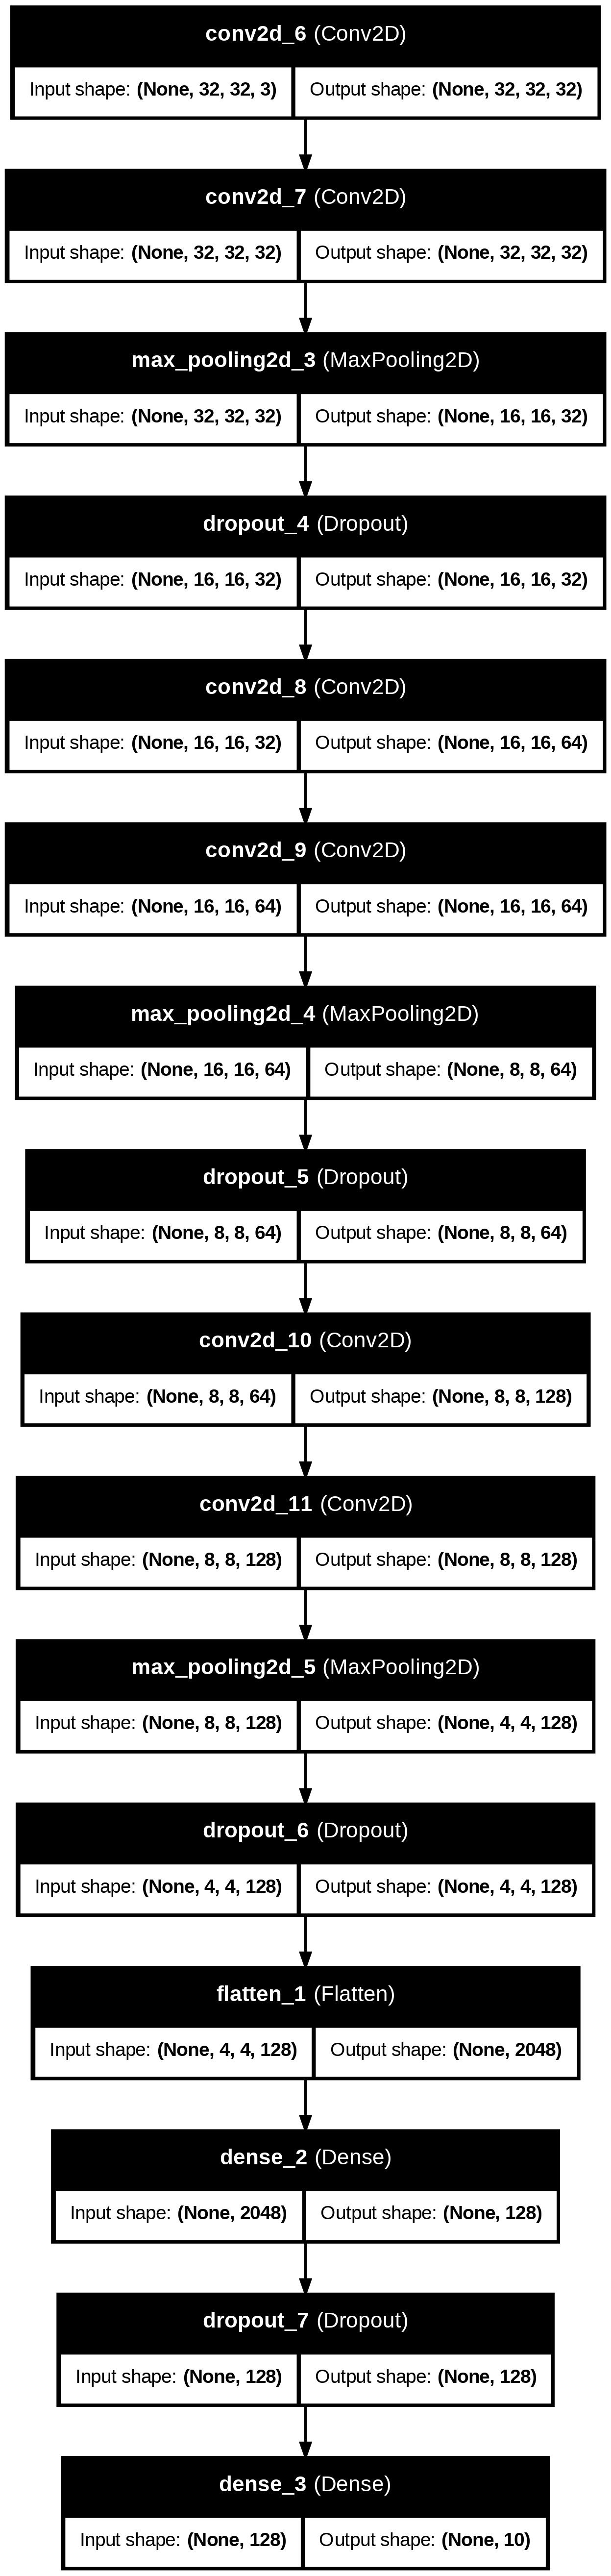

In [8]:
import tensorflow as tf

model = tf.keras.models.load_model('/content/drive/MyDrive/cifar-10-sgd/final_model_sgd_argumentacja_best.keras')


tf.keras.utils.plot_model(model, to_file='architektura.png', show_shapes=True, show_layer_names=True)

